In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load the file from the current directory
df = pd.read_csv('1-2017.csv', sep='\t')

# Display the summary and first few rows
print("{:,} order lines for {:,} orders".format(len(df), df.ORDER_NUMBER.nunique()))
df.head()

144,339 order lines for 59,372 orders


,DATE FORMAT,ORDER_NUMBER,SKU,PCS
0,01/01/2017,835220,290731,1.0
1,01/01/2017,835220,373272,1.0
2,01/01/2017,835214,362101,1.0
3,01/01/2017,835215,215515,1.0
4,01/01/2017,835215,287995,1.0


In [9]:
import pandas as pd

# Pareto Analysis by SKU
# Note: Using 'PCS' from the dataset as the quantity column
df_par = df.groupby(['SKU'])['PCS'].sum().to_frame()
df_par.columns = ['BOX']

# Sort Values descending
df_par.sort_values(['BOX'], ascending=False, inplace=True)
df_par.reset_index(inplace=True)

# Cumulative Sum 
df_par['CumSum'] = df_par['BOX'].cumsum()

# % CumSum (Percentage of total volume)
df_par['%CumSum'] = (100 * df_par['CumSum'] / df_par['BOX'].sum())

# % SKU (Percentage of total unique SKUs)
df_par['%SKU'] = (100 * (df_par.index + 1).astype(float) / (df_par.index.max() + 1))

# Threshold Analysis
# > 80% Volume
df_par80 = df_par[df_par['%CumSum'] > 80].copy()
perc_sku80 = df_par80['%SKU'].min()
perc_sum80 = df_par80['%CumSum'].min()

# 20% SKU
df_sku20 = df_par[df_par['%SKU'] > 20].copy()
perc_sku20 = df_sku20['%SKU'].min()
perc_sum20 = df_sku20['%CumSum'].min()

# 5% SKU
df_sku5 = df_par[df_par['%SKU'] > 5].copy()
perc_sku5 = df_sku5['%SKU'].min()
perc_sum5 = df_sku5['%CumSum'].min()

print("Pareto Analysis for {:,} unique SKU".format(len(df_par)))
print(df_par.head())

Pareto Analysis for 4,864 unique SKU
      SKU     BOX   CumSum    %CumSum      %SKU
0  359803  4810.0   4810.0   2.911658  0.020559
1  290478  4132.0   8942.0   5.412898  0.041118
2  366639  4104.0  13046.0   7.897190  0.061678
3  359958  4062.0  17108.0  10.356058  0.082237
4  253500  3879.0  20987.0  12.704149  0.102796


In [11]:
df_par.tail(4400)

,SKU,BOX,CumSum,%CumSum,%SKU
464,363345,56.0,125213.0,75.795712,9.560033
465,325496,56.0,125269.0,75.829611,9.580592
466,330664,56.0,125325.0,75.863509,9.601151
467,330869,55.0,125380.0,75.896803,9.621711
468,346552,55.0,125435.0,75.930096,9.642270
...,...,...,...,...,...
4859,299866,1.0,165194.0,99.997579,99.917763
4860,299636,1.0,165195.0,99.998184,99.938322
4861,299631,1.0,165196.0,99.998789,99.958882
4862,299630,1.0,165197.0,99.999395,99.979441


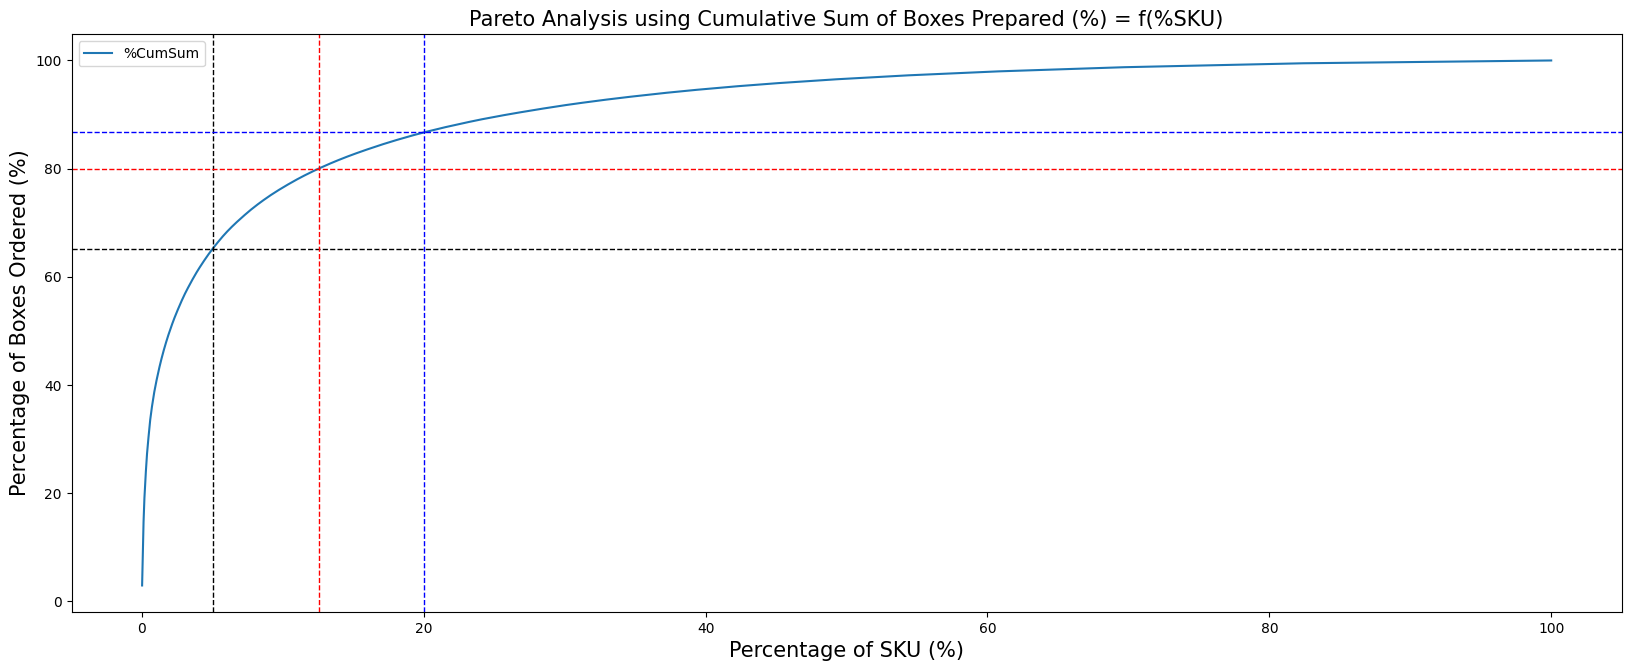

In [13]:
ax = df_par.plot(x='%SKU', y='%CumSum', figsize = (20,7.5))
plt.xlabel('Percentage of SKU (%)',fontsize=15)
plt.ylabel('Percentage of Boxes Ordered (%)',fontsize=15)
plt.title('Pareto Analysis using Cumulative Sum of Boxes Prepared (%) = f(%SKU)', fontsize = 15)
# 5% SKU
ax.axhline(perc_sum5 , color="black", linestyle="--", linewidth = 1.0)
ax.axvline(perc_sku5, color="black", linestyle="--", linewidth = 1.0)
# 80% Volume
ax.axhline(perc_sum80 , color="red", linestyle="--", linewidth = 1.0)
ax.axvline(perc_sku80, color="red", linestyle="--", linewidth = 1.0)
# 20% SKU
ax.axhline(perc_sum20 , color="blue", linestyle="--", linewidth = 1.0)
ax.axvline(perc_sku20, color="blue", linestyle="--", linewidth = 1.0)
plt.show()